In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

# Set up matplotlib defaults for consistent plots
plt.rcParams['figure.figsize'] = (10, 6)  # Standard figure size
plt.rcParams['figure.dpi'] = 100  # Standard resolution

# Font sizes
plt.rcParams['font.size'] = 16  # Base font size
plt.rcParams['axes.titlesize'] = 22  # Plot title
plt.rcParams['axes.labelsize'] = 18  # Axis labels
plt.rcParams['xtick.labelsize'] = 16  # X-axis tick labels
plt.rcParams['ytick.labelsize'] = 16  # Y-axis tick labels
plt.rcParams['legend.fontsize'] = 18  # Legend text

# Line and marker styles
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['lines.markersize'] = 8

# Grid settings
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

# Legend settings
plt.rcParams['legend.frameon'] = True
plt.rcParams['legend.framealpha'] = 0.8
plt.rcParams['legend.edgecolor'] = 'gray'

# Save figure settings
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.2

done generating samples
done clipping
done bounding samples


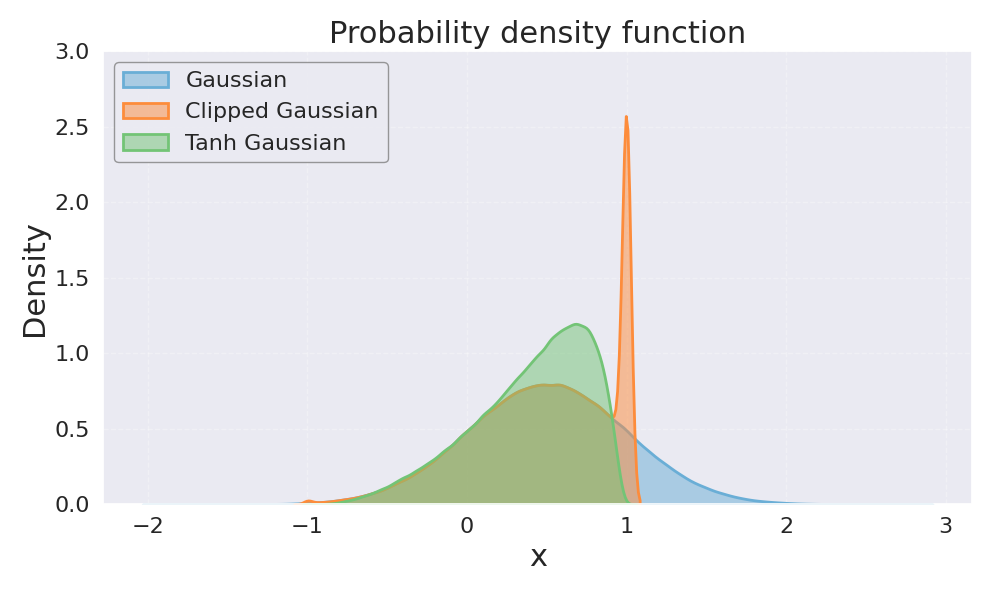

In [8]:
import jax.numpy as np
import jax.random as random



n = 1_000_000

key = random.PRNGKey(0)

original_sample = random.normal(key, shape=(n,))
print("done generating samples")
data = original_sample * 0.5 + 0.5
data2 = data + 0.1

data_bounded = np.clip(data, -1, 1)
data_bounded2 = np.clip(data2, -1, 1)

print("done clipping")

data_tanh = np.tanh(data)
data_tanh2 = np.tanh(data2)

print("done bounding samples")

# Use a seaborn color palette for improved aesthetics
palette = sns.color_palette("viridis", 3)

plt.figure()


sns.kdeplot(np.array(data), fill=True, alpha=0.5, label='Gaussian', color=sns.color_palette("Blues", 1)[0], linewidth=2)
sns.kdeplot(np.array(data_bounded), fill=True, alpha=0.5, label='Clipped Gaussian', color=sns.color_palette("Oranges", 1)[0], linewidth=2)
sns.kdeplot(np.array(data_tanh), fill=True, alpha=0.5, label='Tanh Gaussian', color=sns.color_palette("Greens", 1)[0], linewidth=2)

plt.xlabel('x', fontsize=22)
plt.ylabel('Density', fontsize=22)
plt.title('Probability density function', fontsize=22)
plt.legend(fontsize=16, loc='upper left')
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.ylim(0, 3)  # Bound the y-axis to a maximum of 3
plt.tight_layout()  # Adjust layout to make room for the legend
plt.savefig("./plots/bound/clipped_gaussian.pdf", format="pdf", bbox_inches="tight")
plt.show()


In [9]:
def compute_clipping_ratios(data,data2):

    # Use common bins for both histograms
    bins = np.linspace(min(np.min(data), np.min(data2)),
                    max(np.max(data), np.max(data2)),
                    20)

    # Calculate density histograms
    h1, _ = np.histogram(data, bins=bins, density=True)
    h2, _ = np.histogram(data2, bins=bins, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Compute the ratio (handle division by zero)
    ratio = np.divide(h1, h2, out=np.full_like(h1, np.nan), where=h2>1e-10)

    # Identify the maximum ratio
    max_ratio = np.nanmax(ratio)
    max_index = np.nanargmax(ratio)
    median_ratio = np.nanmedian(ratio)

    # # Plot the ratio vs bin centers and mark the maximum ratio
    # plt.figure(figsize=(10, 6))
    # plt.bar(bin_centers, ratio, width=bins[1]-bins[0], alpha=0.5, label='Probability Ratio (data/data2)')
    # plt.axhline(max_ratio, color='red', linestyle='--', 
    #             label=f'Max Ratio = {max_ratio:.2f} at {bin_centers[max_index]:.2f}')
    # plt.axhline(median_ratio, color='green', linestyle='--',
    #             label=f'Median Ratio = {median_ratio:.2f}')
    # plt.xlabel('Value')
    # plt.ylabel('Probability Ratio')
    # plt.title('Max Ratio Disparity between data and data2')
    # plt.legend()
    # plt.show()
    
    return max_ratio, median_ratio


def compute_kl_divergence(data,data2,plot=False):

    bins = np.linspace(min(np.min(data), np.min(data2)),
                    max(np.max(data), np.max(data2)),
                    50)

    # Calculate density histograms
    h1, _ = np.histogram(data, bins=bins, density=True)
    h2, _ = np.histogram(data2, bins=bins, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    kl_divergence = np.sum(h1 * np.log(h1/h2))

    if plot:
        # Plot the density histograms
        plt.figure(figsize=(10, 6))
        plt.bar(bin_centers, h1, width=bins[1]-bins[0], alpha=0.5, label='Data 1')
        plt.bar(bin_centers, h2, width=bins[1]-bins[0], alpha=0.5, label='Data 2')
        plt.xlabel('Value')
        plt.ylabel('Density')
        plt.title(f'Mean = {data.mean()} std = {data2.std()} and Data 2 KL-Divergence = {kl_divergence:.2f}')
        plt.legend()
        plt.show()
    return bin_centers,h1,h2,kl_divergence



#compute_clipping_ratios(data_bounded,data_bounded2)
#rslt = compute_kl_divergence(data_bounded,data_bounded2)


In [10]:
import jax.numpy as np
import jax.random as random
import itertools
import jax


jax.config.update("jax_enable_x64", True)

ratios = []
means = np.linspace(0, 1., 51)
stds = np.linspace(0.1,1., 51)[::-1]

list = [0.,0.3,0.6,0.9]

bins,hist1 , hist2 = [], [], []

n = 200_000_000

key = random.PRNGKey(0)

original_sample = random.normal(key, shape=(n,))

print("done sampling")


for mean,_ in zip(means[:-1],stds[:-1]): 

    print(mean)

    std = 0.2
    
    data = original_sample * std + mean
    data2 = data + 0.02

    data_bounded = np.clip(data, -1, 1)
    data_bounded2 = np.clip(data2, -1, 1)
    
    #max_ratio, median_ratio = compute_clipping_ratios(data_bounded,data_bounded2)
    #bin,h1,h2,max_ratio = compute_kl_divergence(data_bounded,data_bounded2,plot= mean in list)
    bin,h1,h2,max_ratio = compute_kl_divergence(data_bounded,data_bounded2,plot= False)
    ratios.append(max_ratio)

    if round(mean, 3) in list:

        print(f'RATIOOOOOOOOOOOO {mean} {max_ratio}')
        hist1.append(h1)
        hist2.append(h2)
        bins.append(bin)

done sampling
0.0
RATIOOOOOOOOOOOO 0.0 0.1220649931535181
0.02
0.04
0.06
0.08
0.1
0.12
0.14
0.16
0.18
0.2
0.22
0.24
0.26
0.28
0.3
RATIOOOOOOOOOOOO 0.3 0.13191879844104148
0.32
0.34
0.36
0.38
0.4
0.42
0.44
0.46
0.48
0.5
0.52
0.54
0.56
0.58
0.6
RATIOOOOOOOOOOOO 0.6 0.15693589753489492
0.62
0.64
0.66
0.68
0.7000000000000001
0.72
0.74
0.76
0.78
0.8
0.8200000000000001
0.84
0.86
0.88
0.9
RATIOOOOOOOOOOOO 0.9 0.17491467258419646
0.92
0.9400000000000001
0.96
0.98


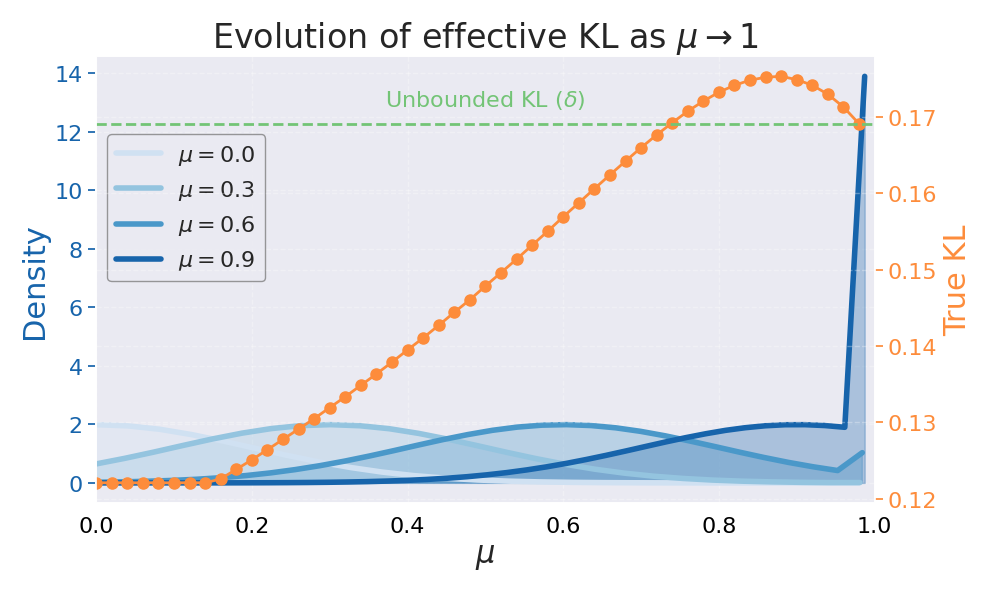

In [22]:
from matplotlib.lines import Line2D

# Create figure with a proper aspect ratio and make sure it's respected
fig, ax1 = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(right=0.85)  # Make room for the second y-axis

num_curves = len(bins)
blue_palette = sns.color_palette("Blues", num_curves)

for i, (bin_centers, h1_hist, h2_hist) in enumerate(zip(bins, hist1, hist2)):
    pdf_color = blue_palette[i]
    ax1.fill_between(bin_centers, h1_hist, color=pdf_color, alpha=0.3)
    ax1.plot(bin_centers, h1_hist, color=pdf_color, lw=4)

ax1.set_xlabel('$\mu$', fontsize=22)
ax1.set_ylabel('Density', color=blue_palette[-1], fontsize=22)
ax1.set_title('Evolution of effective KL as $\mu \\to 1$', fontsize=24)
ax1.tick_params(axis='x', colors='black', labelsize=16)
ax1.tick_params(axis='y', colors=blue_palette[-1], labelsize=16)
ax1.set_xlim(0, 1)  # Restrict x-axis to [0, 1]

kl_color = sns.color_palette("Oranges", 1)[0]
ax2 = ax1.twinx()
ax2.plot(means[:-1], ratios, marker='o', lw=2, color=kl_color)
ax2.set_ylabel('True KL', color=kl_color, fontsize=22)
ax2.tick_params(axis='y', colors=kl_color, labelsize=16)

line_color = sns.color_palette("Greens", 1)[0]

_, _, _, kl_ref = compute_kl_divergence(data_bounded, data_bounded2, plot=False)
ax2.axhline(kl_ref, color=line_color, linestyle='--', lw=2)
x_mid = means[:-1][len(means[:-1]) // 2]
# Position the text ABOVE the line for better visibility
ax2.text(x_mid, kl_ref*1.01, "Unbounded KL ($\\delta$)", color=line_color, ha='center', va='bottom', fontsize=16)

# Add a legend for the blue curves with better positioning
legend_elements = []
for i, val in enumerate([0.0, 0.3, 0.6, 0.9]):
    legend_elements.append(Line2D([0], [0], color=blue_palette[i], lw=4, 
                                 label=f'$\mu = {val}$'))
ax1.legend(handles=legend_elements, loc='upper left', fontsize=16, bbox_to_anchor=(0.0, 0.85))

# Ensure figure has correct aspect ratio
plt.tight_layout()
plt.savefig("./plots/bound/histogram_combined.pdf", format="pdf", bbox_inches="tight")
plt.show()


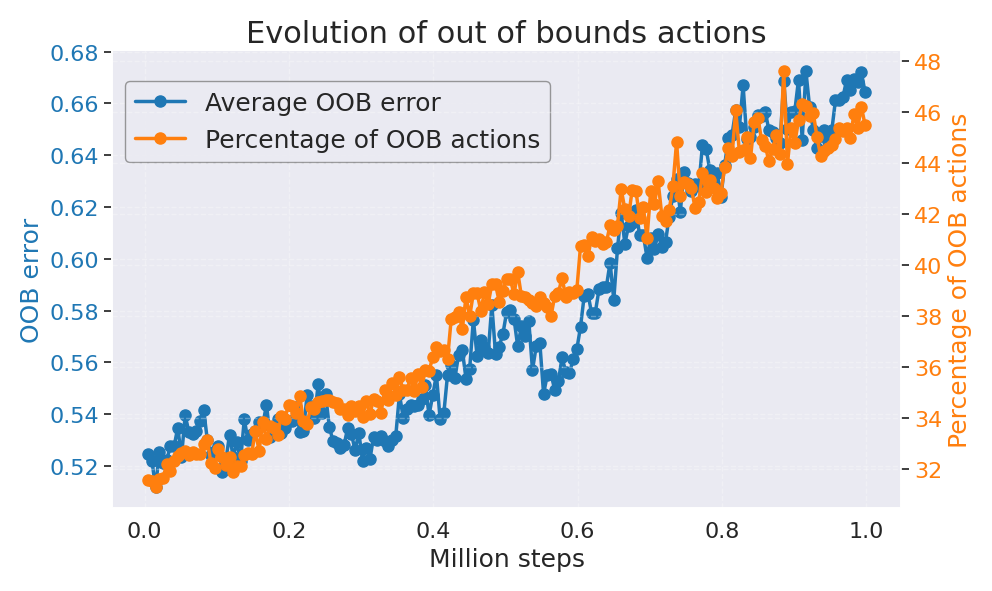

In [12]:
import pandas as pd
import wandb
import os


os.environ["WANDB_API_KEY"]="28996bd59f1ba2c5a8c3f2cc23d8673c327ae230"
api = wandb.Api()
entity = "mahdikallel"
project_name = "PPO_OUTBOUND"
runs = api.runs(entity + "/" + project_name)

# Select one run from the list
run = runs[0]

# Retrieve the run's history containing the necessary metrics
history = run.history(samples=1000000).dropna(subset=["training/out_of_bound_percentage"])


# Create a single figure
fig, ax1 = plt.subplots()

# Plot OOB error on the first y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Million steps')
ax1.set_ylabel('OOB error', color=color1)
ax1.plot(history["_step"]/1e6, history["OOB_error"], marker='o', color=color1, label="Average OOB error")
ax1.tick_params(axis='y', labelcolor=color1)
ax1.tick_params(axis='x')

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()
color2 = 'tab:orange'
ax2.set_ylabel('Percentage of OOB actions', color=color2)
ax2.plot(history["_step"]/1e6, history["training/out_of_bound_percentage"], marker='o', color=color2, label="Percentage of OOB actions")
ax2.tick_params(axis='y', labelcolor=color2)

# Add title
plt.title("Evolution of out of bounds actions")

# Add legend for both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(0.0, 0.96))

plt.tight_layout()
plt.savefig("./plots/bound/error.pdf", format="pdf", bbox_inches="tight")  
plt.show()
